In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# Color codes from the image
main_colors = ['#5a9bd5', '#ed7d31', '#70ad46', '#a5a5a5']
darker_colors = ['#4473c5', '#c55b11', '#538234', '#7c7c7c']
lighter_colors = ['#deeaf6', '#fbe5d7', '#e2f0d9', '#ededed']

In [3]:
import json
def read_json(data_path):
    # Reading JSON from a file
    with open(data_path, 'r') as file:
        data = json.load(file)
    return data

def save_json(data_path, data_dict):
    # Write dictionary to JSON file  
    with open(data_path, 'w') as f:  
        json.dump(data_dict, f)  

import pickle
def read_pkl(data_path):
    with open(data_path, 'rb') as file:
        data = pickle.load(file)
    return data

def save_pkl(data_path, data_dict):
    with open(data_path, 'wb') as file:
        pickle.dump(data_dict, file)


# Figure 3b

In [4]:
rul_preds = read_pkl('/data/rul_baseline_predictions.pkl')

In [5]:
errors = {}
for key, item in rul_preds.items():
    if key == 'ours_relative_direct_without_smoother_without_differ_':
        key = 'ours'
    if key == 'PLSR':
        item = [[i[0],np.squeeze(i[1])] for i in item]
    if key == 'log 10 (var(ΔQ100−10 (V)))':
        key = 'Variance model'
    if key == 'discharge' or key == 'full':
        key = key + 'model'


    # key = key.capitalize()
    key = key[0].upper() + key[1:]

    item = np.array(item)
    cumulative_squared_errors = np.sqrt(np.cumsum((item[:,1,] - item[:,0,]) ** 2, axis=1))
    errors[key] = cumulative_squared_errors.mean(axis=0)
    errors[key] = np.insert(errors[key], 0, 0)


In [6]:
import matplotlib.cm as cm
def plot_error_curve(errors, save_fig_path = None, mask_font=False):
    

    # Color codes from the image
    main_colors = ['#5a9bd5', '#ed7d31', '#70ad46', '#a5a5a5']
    darker_colors = ['#4473c5', '#c55b11', '#538234', '#7c7c7c']
    lighter_colors = ['#deeaf6', '#fbe5d7', '#e2f0d9', '#ededed']

    color_palette = [
        # Muted Blues
        "#53565c",  # Darkest Muted Blue
        "#D2E2E9",  # Lightest Muted Blue
        "#BFD6E3",
        "#A6C9DC",
        "#8DBCD5",
        "#74AFCE",
        "#5BA2C7",
        "#4285B7",
        "#2B68A7",  # Darkest Muted Blue

        # Muted Purples
        "#9c64a7",
        "#c1a1ca",
        "#e3c6cf",

        # Muted Greens (Based on #70AD46)
        "#70AD46",  # Darkest Muted Green
        "#62be9d"   # Lightest Muted Green
    ]

    plt.figure(figsize=(8, 6))

    ours_color = '#ed7d31'

    # Plot each item with colors from the colormap, except 'ours'
    colors = {}
    for i, (key, item) in enumerate(errors.items()):
        if key == 'Ours':
            plt.plot(item, label=key, linewidth=2, color=ours_color)
            colors[key] = ours_color
        else:
            # Reduce saturation by blending with white
            color = color_palette[i]
            plt.plot(item, label=key, linewidth=2, color=color)
            colors[key] = color


    # Add grid
    plt.grid(True, linestyle='--', alpha=0.7)
    

    plt.title('Comparison of Methods', fontsize=16)
    plt.xlabel('Evaluated Battery Count', fontsize=14)
    plt.ylabel('Cumulative Prediction Error(RMSE)', fontsize=14)


    # Adjust font sizes
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)



    if mask_font:
        plt.gca().set_yticklabels([])
        plt.title('')
        plt.xlabel('')
        plt.ylabel('')
        plt.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=False, labelsize=14)
        plt.tick_params(axis='y', which='both', left=True, right=False, labelleft=False, labelsize=14)
        # plt.legend(handles, [' '*25 for c in colors], fontsize=14)

        
    else:
        sorted_errors= dict(sorted(errors.items(), key=lambda item: item[1][-1], reverse=True)) 

        labels = list(sorted_errors.keys())  # specify the order of the labels  

        # plt.legend(handles, colors.keys(), fontsize=14, loc='upper right')
        plt.legend(labels = labels, loc='upper left', bbox_to_anchor=(1, 1.0), fontsize=15, frameon=False, handles=[plt.Line2D([0], [0], color=colors[label], lw=2) for label in labels])
        # Display the plot
        

    if save_fig_path:
        fig_format = save_fig_path.split('.')[-1]
        plt.savefig(save_fig_path, format=fig_format, bbox_inches='tight', pad_inches=0.1)
        
    else:
        plt.tight_layout()
        plt.show()


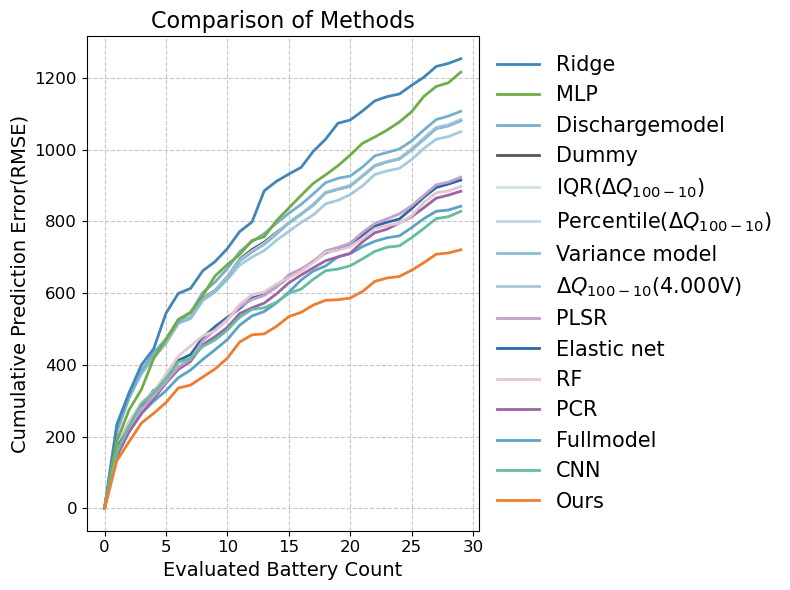

In [7]:
plot_error_curve(errors, save_fig_path = '/results/3b.png')

# Figure 3d

In [8]:
# read data
rul_feature_importance = pd.read_csv('/data/feature_importance_rul.csv')

In [9]:
rul_feature_importance

,Unnamed: 0,feature_name,score
0,0,identity(nanmax(Cycle(6/7))[nanvar(VQ_d(1/4))]),0.041011
1,1,abs(nanmean(Cycle(3/7) - Cycle(6/7))[nanmean(V...,0.027796
2,2,abs(nanmax(Cycle(6/7))[nanvar(VQ_d(1/4))]),0.027792
3,3,identity(nanmean(Cycle(4/7) - Cycle(6/7))[nanm...,0.020960
4,4,identity(nanmean(Cycle(3/7) - Cycle(6/7))[nanm...,0.020626
...,...,...,...
315,315,identity(nanmax(Cycle(6/7))[nanvar(VQ_d(1/4))]),0.008072
316,316,identity(nanmax(Cycle(4/7) - Cycle(7/7))[nanma...,0.007984
317,317,abs(nanvar(Cycle(7/7))[nanmin(VQ_d(1/4))]),0.007888
318,318,abs(nanmin(Cycle(4/7) - Cycle(5/7))[nanvar(QV_...,0.007743


In [10]:
import re
def get_op(s):    
    cycles = re.findall(r'Cycle\(.*?\)', s)
    cycles_str = ' - '.join(cycles)

    patterns = ['VQ_c', 'VQ_d', 'dVdQ_c', 'dVdQ_d', 'I_c', 'I_d', 'V_c', 'V_d', 'QV_c', 'QV_d', 'E_c', 'W_c', 'E_d', 'W_d']


    pattern = '|'.join(f"{re.escape(p)}\\(\\d+/\\d+\\)" for p in patterns)    

    compiled_pattern = re.compile(pattern)
    match = compiled_pattern.search(s)
    if match:
        qv = match.group()

    
    news = s.replace(cycles_str, '').replace(qv, '')  
    parts = re.findall(r'\b\w+\b|\([^()]*\)', news)
    parts = [i.strip('()') for i in parts]

    return cycles_str, qv, parts
    
def add2dic(dic, key, score=1):
    if key in dic.keys():
        dic[key]+=score
    else:
        dic[key]=score


def count_op(cycles_str, qv, parts, dic, score=1):
    ops = [
        'clipped_log_abs', 'sqrt_abs', 'clipped_exp', 'square', 'sqrt_abs','identity',
        'min', 'nanmean', 'max', 'mean', 'var', 'nanmax', 'nanmedian', 'kurtosis',
    ]
    
    if cycles_str:
        add2dic(dic, cycles_str, score=score)
    if qv:
        add2dic(dic, qv, score=score)
    for i in parts:
        if i != '[]' and i !='':
            add2dic(dic, i, score=score)
    return dic
            
def classify(s):
    patterns = ['VQ_c', 'VQ_d', 'dVdQ_c', 'dVdQ_d', 'I_c', 'I_d', 'V_c', 'V_d', 'QV_c', 'QV_d', 'E_c', 'W_c', 'E_d', 'W_d']
    if 'Cycle' in s:
        return 'cycle'
    elif  s.split('(')[0] in patterns:
        return 'in_cycle'
    elif s == 'abs' or s == 'identity':
        return 'activators'
    else:
        return 'aggregators'


In [11]:
def process_feature_importance(feature_importance):
    dic = {}
    for index, items in feature_importance.iterrows():
        cycles_str,  qv, parts = get_op(items['feature_name'])
        dic = count_op(cycles_str,  qv, parts, dic, score=items['score'])

    op_imp = pd.DataFrame(list(dic.items()), columns=['op', 'score'])

    op_imp['class'] = op_imp['op'].apply(lambda x: classify(x))

    agg_index = op_imp[op_imp['class'] == 'aggregators'].index
    op_imp.loc[agg_index,  'score'] = op_imp.loc[agg_index,  'score']/2
    op_imp = op_imp.sort_values(by='score', ascending=False)

    op_imp = op_imp[op_imp['class'] != 'activators']
    return op_imp

import seaborn as sns

def plot_feature_importance(df, title='', save_fig_path=None, mask_font=False):
    plt.figure()
    colors = { 'aggregators':  main_colors[1], 'cycle':  main_colors[2], 'in_cycle': main_colors[0]}
    df = df.head(20)
    # Create a bar plot

    plt.barh(df['op'], df['score'], color=df['class'].map(colors), alpha=0.7)


    # Add labels and title
    plt.ylabel('Operation')
    plt.xlabel('Score')
    plt.title(title)
    

    # Add a legend
    handles = [plt.Rectangle((0,0),1,1, color=colors[label], alpha=0.7) for label in colors]
    plt.gca().yaxis.set_ticks_position('right')


    plt.xlim(df['score'].max(), 0)  # Set x-axis limits  


    if mask_font:
        plt.gca().set_yticklabels([])
        plt.title('')
        plt.xlabel('')
        plt.ylabel('')
        plt.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=False, labelsize=14)
        plt.tick_params(axis='y', which='both', left=False, right=True, labelleft=False, labelsize=14)


    if save_fig_path:
        fig_format = save_fig_path.split('.')[-1]
        plt.savefig(save_fig_path, format=fig_format, bbox_inches='tight', pad_inches=0.1)
        
    else:
        plt.tight_layout()
        plt.show()

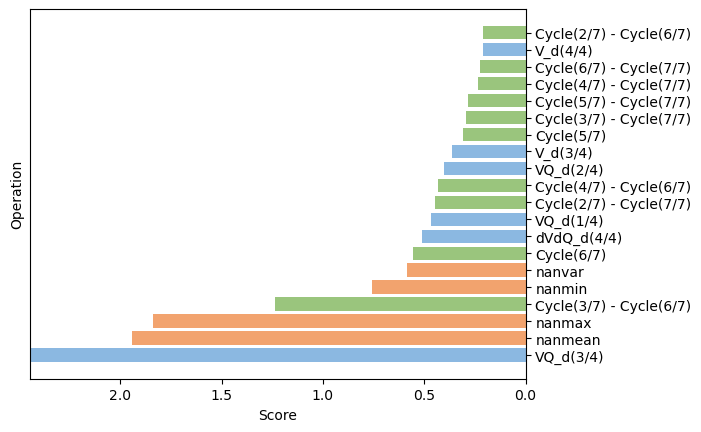

In [12]:
# cycle 7
op_imp = process_feature_importance(rul_feature_importance)

plot_feature_importance(op_imp, title='', save_fig_path='/results/3d.png')

# knee point feature

In [13]:
mdc_feature_importance = pd.read_csv('/data/feature_importance_kneepoint.csv')

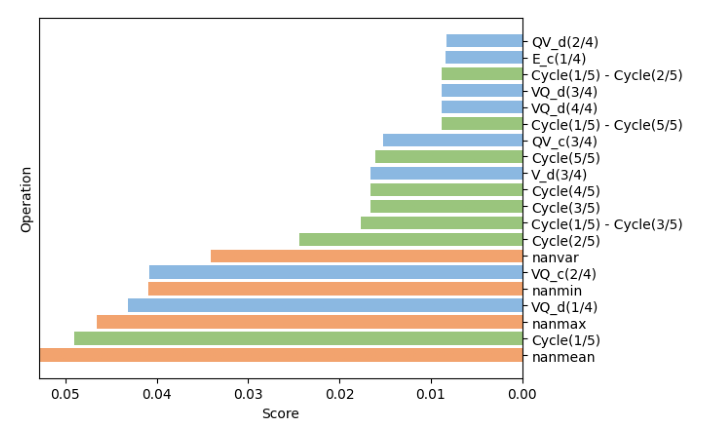

In [14]:
op_imp = process_feature_importance(mdc_feature_importance)
plot_feature_importance(op_imp, title='', save_fig_path='/results/feature_knee_point.png')
# plot_feature_importance(op_imp, title='', save_fig_path='/results/feature_knee_point.svg', mask_font=True)

# XPS feature importance


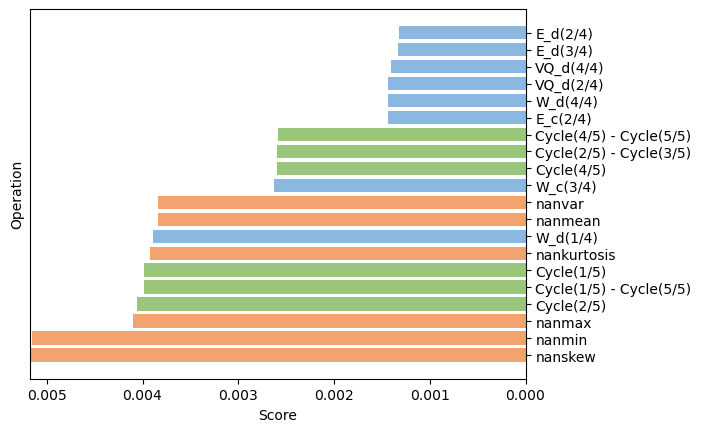

In [15]:
xps_feature_importance = pd.read_csv('/data/feature_importance_xps.csv')
op_imp = process_feature_importance(xps_feature_importance)
plot_feature_importance(op_imp, title='', save_fig_path='/results/4c.png')
# plot_feature_importance(op_imp, title='', save_fig_path='/results/4c.svg', mask_font=True)